# U.S. Medical Insurance Cost Analysis

This project explores how factors such as age, BMI, smoking status,
and region are associated with medical insurance charges.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the Dataset

In [2]:
df = pd.read_csv('insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Overview 

This dataset was provided as part of a Codecademy portfolio project and appeared to be largely pre-cleaned. I still performed basic data quality checks for missing values, data types, and duplicate records before analysis. 

In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
df = df.drop_duplicates().copy()

df.duplicated().sum()

np.int64(0)

### Data Cleaning 

The dataset contained no missing values. One duplicate record was identified and removed before moving on to analysis. 

### Descriptive Statistics

I calculated summary statistics to better undrstand the overall characteristics of the data set before exploring relationships between variables.

In [9]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.describe(include='object')

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [11]:
avg_age = df.age.mean()
avg_bmi = df.bmi.mean()
avg_children = df.children.mean()
avg_charges = df.charges.mean()

print(f'Average age: {avg_age:.1f} years')
print(f'Average BMI: {avg_bmi:.2f}')
print(f'Average number of children: {avg_children:.2f}')
print(f'Average insurance charge: ${avg_charges:,.2f}') 

Average age: 39.2 years
Average BMI: 30.66
Average number of children: 1.10
Average insurance charge: $13,279.12


### Summary

The average individual in the dataset is approximately 39.2 years old, has a BMI of 30.66, and has 1.10 children. The aveage medical insurance charge is approximately $13,279.12.


## Distribution of Medical Insurance Charges

Before comparng insurance charges across different groups, I examined the overall distributions of charges to understand their spread, skew, and the presence of unusually high values. 

In [12]:
df.charges.describe()

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

In [13]:
mean_charge = df.charges.mean()
median_charge = df.charges.median()

print(f'Mean charge: ${mean_charge:,.2f}')
print(f'Median charge: ${median_charge:,.2f}')

Mean charge: $13,279.12
Median charge: $9,386.16


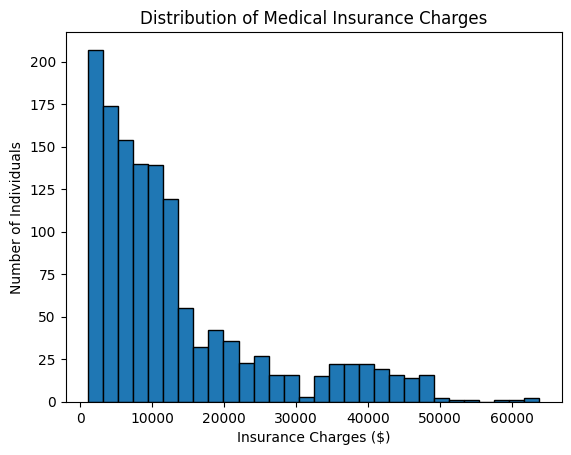

In [14]:
plt.hist(df.charges, bins=30, edgecolor='black')

plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Insurance Charges ($)')
plt.ylabel('Number of Individuals')
plt.show()

### Findings 
Medical Insurance charges are right skewed, with most individuals having lower-to-moderate charges and a smaller number of indiviuals with very high charges. 
The mean charge is $13,279.12, while the median is $9,386.16. Because the mean is noticeably higher than the median, higher-cost observations are pulling the average upward. 
This suggests that average charges alone may not fully represent a typical individual in the data set, so both mean and median values should be considered in later comparisons. 

## Smoking Status and Insurance Charges

Since the distribution of insurance charges is right skewed, I compared both the mean and median charges for smokers and non-smokers. This helps determine whether differences in average charges are also reflected in the typical cost within each group.

In [15]:
smoking_summary = df.groupby('smoker').charges.agg(
    count='count',
    mean='mean',
    median='median',
    std='std'
)

smoking_summary

,count,mean,median,std
smoker,,,,
no,1063,8440.660307,7345.72660,5992.973800
yes,274,32050.231832,34456.34845,11541.547176


In [16]:
smoker_mean = smoking_summary.loc['yes', 'mean']
nonsmoker_mean = smoking_summary.loc['no', 'mean']

smoker_median = smoking_summary.loc['yes', 'median']
nonsmoker_median = smoking_summary.loc['no', 'median']

mean_diff = smoker_mean - nonsmoker_mean
mean_percent_diff = (mean_diff / nonsmoker_mean) * 100

median_diff = smoker_median - nonsmoker_median
median_percent_diff = (median_diff / nonsmoker_median) * 100

print(f"Mean charge for smokers: ${smoker_mean:,.2f}")
print(f"Mean charge for non-smokers: ${nonsmoker_mean:,.2f}")
print(f"Mean difference: ${mean_diff:,.2f}")
print(f"Smokers have {mean_percent_diff:.1f}% higher mean charges.")

print()

print(f"Median charge for smokers: ${smoker_median:,.2f}")
print(f"Median charge for non-smokers: ${nonsmoker_median:,.2f}")
print(f"Median difference: ${median_diff:,.2f}")
print(f"Smokers have {median_percent_diff:.1f}% higher median charges.")

Mean charge for smokers: $32,050.23
Mean charge for non-smokers: $8,440.66
Mean difference: $23,609.57
Smokers have 279.7% higher mean charges.

Median charge for smokers: $34,456.35
Median charge for non-smokers: $7,345.73
Median difference: $27,110.62
Smokers have 369.1% higher median charges.


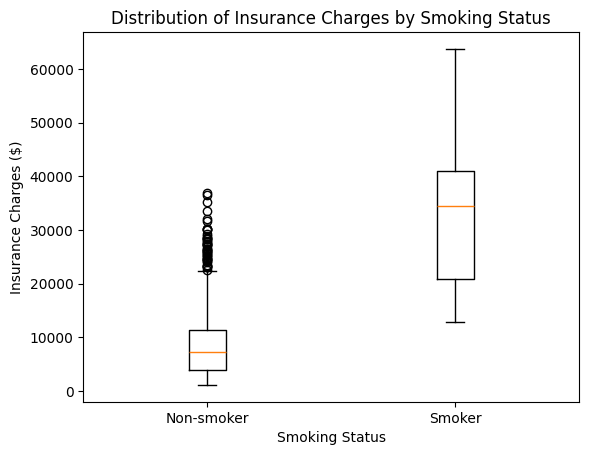

In [17]:
nonsmoker_charges = df[df.smoker == 'no']['charges']
smoker_charges = df[df.smoker == 'yes']['charges']

plt.boxplot(
    [nonsmoker_charges, smoker_charges],
    tick_labels=['Non-smoker', 'Smoker']
)

plt.title('Distribution of Insurance Charges by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Insurance Charges ($)')
plt.show()

### Finding 
Smoking status is strongly associated with higher insurance charges in this data set. Smokers had a mean charge of $32,050.23 compared with $8,440.66 for non-smokers, making the mean charge for smokers approximately 279.7% higher. 
The difference is even larger when comparing medians. The median charge for smokers was $34,456.35 compared with $7,345.73, a difference of approximately 369.1%.
The boxplot also shows several high-cost outliers among non-smokers. These observations raise the non-smoker mean above the median, which reinforces why examining both measures in useful for this data set.
Overall, smoking status appears to have a strong association with insurance charges, although this observational analysis does not establish causation. 

## BMI, Smoking Status, and Insurance Charges
Since smoking status showed a strong associatoion with insurance charges, I examined whether the relationships between BMI and charges differs between smokers and non-smokers. 
Rather than analyzing BMI independently, this section compares the relationship within each smoking group. 

In [18]:
smokers = df[df.smoker == 'yes']
non_smokers = df[df.smoker == 'no']

print(f'Smokers: {len(smokers)}')
print(f'Non-smokers: {len(non_smokers)}')

Smokers: 274
Non-smokers: 1063


In [19]:
smoker_bmi_corr = smokers.bmi.corr(smokers.charges)
nonsmoker_bmi_corr = non_smokers.bmi.corr(non_smokers.charges)

print(f'BMI and charge correlation among smokers: {smoker_bmi_corr:.2f}')
print(f'BMI and charge correlation among non smokers: {nonsmoker_bmi_corr:.2f}')

BMI and charge correlation among smokers: 0.81
BMI and charge correlation among non smokers: 0.08


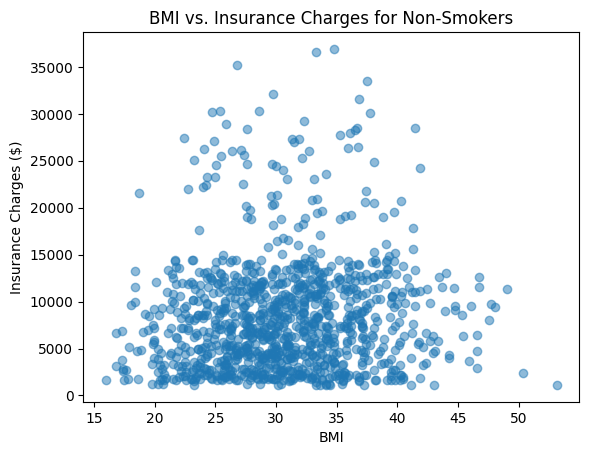

In [20]:
plt.scatter(
    non_smokers.bmi,
    non_smokers.charges,
    alpha=0.5
)

plt.title("BMI vs. Insurance Charges for Non-Smokers")
plt.xlabel('BMI')
plt.ylabel('Insurance Charges ($)')
plt.show()

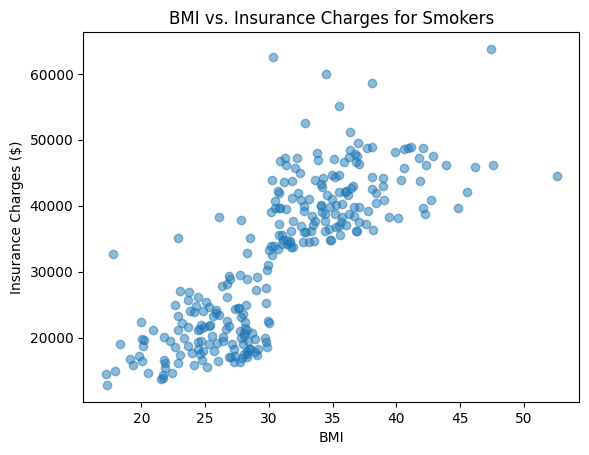

In [21]:
plt.scatter(
    smokers.bmi,
    smokers.charges,
    alpha=0.5
)

plt.title("BMI vs. Insurance Charges for Smokers")
plt.xlabel('BMI')
plt.ylabel('Insurance Charges ($)')
plt.show()

In [22]:
bmi_bins = [0, 18.5, 25, 30, float("inf")]

bmi_labels = [
    "Underweight",
    "Healthy",
    "Overweight",
    "Obesity"
]

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=bmi_bins,
    labels=bmi_labels,
    right=False
)

df[["bmi", "bmi_category"]].head()

,bmi,bmi_category
0,27.900,Overweight
1,33.770,Obesity
2,33.000,Obesity
3,22.705,Healthy
4,28.880,Overweight


In [23]:
bmi_smoking_summary = df.groupby(
    ['bmi_category', 'smoker'],
    observed=False
)['charges'].agg(
    count='count',
    mean='mean',
    median='median'
)

bmi_smoking_summary

count          mean       median
bmi_category smoker                                  
Underweight  no         15   5532.992453   3732.62510
             yes         5  18809.824980  15006.57945
Healthy      no        175   7685.656014   6593.50830
             yes        50  19942.223641  19479.90370
Overweight   no        312   8257.961955   7063.91570
             yes        74  22495.874163  21215.43300
Obesity      no        561   8855.531349   8083.91980
             yes       145  41557.989840  40904.19950

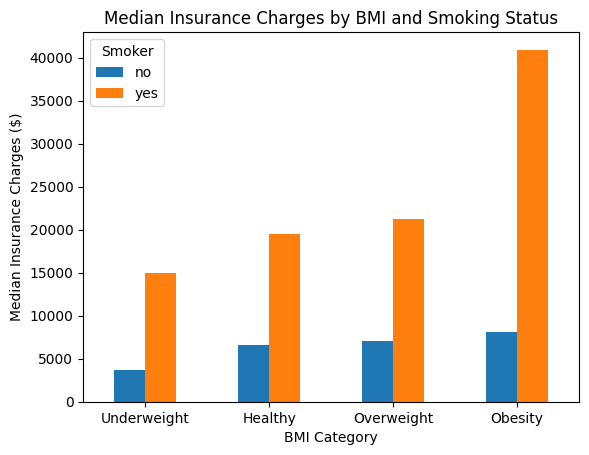

In [26]:
bmi_smoking_median.plot(kind="bar")

plt.title("Median Insurance Charges by BMI and Smoking Status")
plt.xlabel("BMI Category")
plt.ylabel("Median Insurance Charges ($)")
plt.xticks(rotation=0)
plt.legend(title="Smoker")
plt.show()

### Finding 
The relationship between BMI and insurance charges differs substantially by smoking status.
Among smokers, BMI has a strong positive correlation with insurance charges (r = 0.81), while the correlation among non-smokers is very weak (r = 0.08). This suggests that higher BMI is much more strongly associated with higher insurance charges for smokers than for non-smokers.
The grouped median comparison shows the same pattern. Median charges for non-smokers increase gradually across BMI categories, while smokers with obesity have substantially higher median insurance charges than smokers in lower BMI categories.
This indicates that BMI alone does not explain higher insurance costs. Instead, BMI appears to have a much stringer relationship with charges when combined with smoking status.


The underweight smoker group only contains 5 individuals, so results from that category should be interpreted cautiously due to small sample size.